# ABSA with T5 + LoRA and XAI Visualization
This code implements an end-to-end T5+LoRA-based Aspect-Based Sentiment Analysis (ABSA) model training and interpretability workflow: first, the CSV files from the SemEval2015 dataset are loaded and filtered using DataLoaderPreprocessor, sentences, aspect words, and their positions are extracted, and they are converted into a list of records; then, the text is segmented, and construct BIO annotation sequences and sentiment labels in a custom ABSADataset, while organising batch iterations through DataLoader. Next, load the T5ForConditionalGeneration model and apply the LoRA adapter to reduce the number of parameters during fine-tuning, then define ABSAHead to perform BIO annotation and sentiment classification prediction on the model's hidden layer outputs, and combine with the cross-entropy loss function to achieve joint training; during training, use torch.cuda.amp for mixed-precision training to improve efficiency, and accumulate prediction results with ground truth labels to calculate BIO F1 and sentiment classification accuracy; after training, use Matplotlib to plot confusion matrices for sentiment classification and BIO annotation to visually assess model performance; finally, use LIME to provide local interpretability for sentiment predictions of single sentence inputs, and analyse the impact of key words on predictions for specific categories.

In [1]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
!{sys.executable} -m pip install --upgrade "huggingface-hub>=0.30.0,<1.0" transformers
import warnings
warnings.filterwarnings("ignore", message="h5py is running against HDF5")


  Obtaining dependency information for huggingface-hub<1.0,>=0.30.0 from https://files.pythonhosted.org/packages/33/c7/852d4473788cfd7d79b73951244b87a6d75fdac296c90aeb5e85dbb2fb5e/huggingface_hub-0.31.4-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/489.3 kB ? eta -:--:--
   --------- ------------------------------ 112.6/489.3 kB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 489.3/489.3 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.31.2
    Uninstalling huggingface-hub-0.31.2:
      Successfully uninstalled huggingface-hub-0.31.2


In [13]:
import glob
import warnings
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report
from transformers import AutoTokenizer, T5ForConditionalGeneration
from peft import get_peft_model, LoraConfig, TaskType
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm, trange

# ========== Configuration Parameters ==========
# Recursively scan all CSV files including subfolders
CSV_GLOB       = r"E:/ABSA-LLM-XAI/dataset/SemEval2015/**/*.csv"
TEXT_COL       = "text"
ASPECT_COL     = "category"
LABEL_COL      = "polarity"                     # Sentiment label column name
MAX_LEN        = 128                             # Max text length
BATCH_SIZE     = 8                               # Batch size
EPOCHS         = 20                               # Number of epochs
LR             = 2e-4                            # Learning rate
BACKBONE       = "t5-base"                      # Pretrained T5 model
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
ENABLE_XAI_VIS = True                            # Whether to enable XAI visualization
warnings.filterwarnings("ignore")                # Suppress warnings


In [ ]:
# LIME
try:
    from lime.lime_text import LimeTextExplainer
except ImportError:
    LimeTextExplainer = None
    print("WARNING: 'lime' module is not installed. LIME visualization will be skipped. Please run `pip install lime` to enable it.", flush=True)

## Data Loading and Preprocessing

In [4]:
class DataLoaderPreprocessor:
    def load_files(self, paths):
        """
        Scan all CSVs in specified paths, keep only those with required columns, and concatenate.
        """
        dfs = []
        for p in paths:
            try:
                df = pd.read_csv(p)
                if not all(c in df.columns for c in [TEXT_COL, ASPECT_COL, LABEL_COL]):
                    continue
                dfs.append(df[[TEXT_COL, ASPECT_COL, LABEL_COL] + (["target"] if "target" in df.columns else [])])
            except Exception:
                continue
        if not dfs:
            raise FileNotFoundError(
                f"No valid CSV files found. Check path ({CSV_GLOB}) and column names ({TEXT_COL}, {ASPECT_COL}, {LABEL_COL})."
            )
        return pd.concat(dfs, ignore_index=True)


def load_records():
    """
    Load and construct record list. Each record contains:
      - Sentence: original review text
      - from_ / to: start/end indices of the aspect term in text
      - polarity: sentiment label (lowercased)
    """
    file_paths = glob.glob(CSV_GLOB, recursive=True)
    print(f"Found {len(file_paths)} CSV files:")
    for fp in file_paths:
        print("  ", fp)

    df = DataLoaderPreprocessor().load_files(file_paths)
    print("CSV Columns:", df.columns.tolist())

    aspect_source = "target" if "target" in df.columns and df["target"].notna().sum() > 0 else ASPECT_COL
    print(f"Using '{aspect_source}' as aspect term column.")

    df["aspect_term"] = df[aspect_source].astype(str).apply(lambda x: x.split("#")[-1].strip())

    df["from"] = df.apply(lambda r: r[TEXT_COL].lower().find(r["aspect_term"].lower()), axis=1)
    df["to"]   = df["from"] + df["aspect_term"].str.len()

    rec = []
    for _, r in df.iterrows():
        if r["from"] >= 0:
            rec.append({
                "Sentence": r[TEXT_COL],
                "from_": int(r["from"]),
                "to": int(r["to"]),
                "polarity": r[LABEL_COL].lower()
            })
    print(f"Loaded {len(rec)} valid records.")
    return rec

# Execute data loading
records = load_records()
# Build label set and mapping
label_set = sorted({r["polarity"] for r in records})
pol2id    = {lab: idx for idx, lab in enumerate(label_set)}
NUM_SENT  = len(pol2id)
print('module complete')

Found 2 CSV files:
   E:/ABSA-LLM-XAI/dataset/SemEval2015\Laptops.csv
   E:/ABSA-LLM-XAI/dataset/SemEval2015\Restaurants.csv
CSV Columns: ['text', 'category', 'polarity', 'target']
Using 'target' as aspect term column.
Loaded 10013 valid records.
module complete


## Dataset and DataLoader

In [5]:
# Load the tokenizer from the specified pre-trained backbone model
tok = AutoTokenizer.from_pretrained(BACKBONE)

class ABSADataset(Dataset):
    """
    A custom PyTorch Dataset class for Aspect-Based Sentiment Analysis (ABSA).

    Each sample contains:
      - Tokenized sentence with padding/truncation
      - BIO labels indicating aspect term positions
      - Sentiment label corresponding to the aspect term
    """

    def __init__(self, recs):
        """
        Initialize the dataset with raw records and encode each sample.

        Parameters:
            recs (list[dict]): List of input records with 'Sentence', 'from_', 'to', and 'polarity' keys.
        """
        self.data = [self.encode(r) for r in recs]

    def encode(self, r):
        """
        Tokenize a single record and generate its BIO and sentiment labels.

        Parameters:
            r (dict): A dictionary with keys 'Sentence', 'from_', 'to', and 'polarity'.

        Returns:
            dict: A dictionary containing input_ids, attention_mask, and both label types.
        """
        # Tokenize the sentence while retaining character offsets
        enc = tok(
            r["Sentence"],
            return_offsets_mapping=True,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN
        )

        offsets = enc.pop("offset_mapping")  # Remove and store offset mappings
        bio = []  # BIO label list initialization

        for s, e in offsets:
            if s == e == 0:
                bio.append(-100)  # Padding token: ignored during loss calculation
            elif s >= r["from_"] and e <= r["to"]:
                # Label "B" if start of aspect, otherwise "I"
                bio.append(1 if s == r["from_"] else 2)
            else:
                bio.append(0)  # Outside any aspect

        # Add BIO and sentiment labels to the encoded dictionary
        enc["labels_bio"]  = bio
        enc["labels_sent"] = pol2id[r["polarity"]]  # Convert polarity string to label id
        return enc

    def __len__(self):
        """
        Return the number of samples in the dataset.
        """
        return len(self.data)

    def __getitem__(self, i):
        """
        Retrieve the i-th item from the dataset, converting all values to PyTorch tensors.

        Parameters:
            i (int): Index of the item to retrieve.

        Returns:
            dict: A dictionary of tensors (input_ids, attention_mask, labels_bio, labels_sent).
        """
        return {k: torch.tensor(v) for k, v in self.data[i].items()}

# Create the dataset and DataLoader
dataset = ABSADataset(records)
print(f"Dataset size: {len(dataset)} samples.")

# Create a DataLoader to batch and shuffle the data during training
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print('module complete')


Dataset size: 10013 samples.
module complete


## Model Setup with LoRA

In [6]:
# Load the pre-trained T5 model for sequence-to-sequence generation
base = T5ForConditionalGeneration.from_pretrained(BACKBONE)

# Configure LoRA (Low-Rank Adaptation) for parameter-efficient fine-tuning
# - task_type: sequence-to-sequence language modeling
# - r: low-rank dimension
# - lora_alpha: scaling factor
# - lora_dropout: dropout probability applied to the low-rank adapters
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1
)

# Wrap the base model with the LoRA adapters and move it to the chosen device (GPU or CPU)
base = get_peft_model(base, lora_cfg).to(DEVICE)

class ABSAHead(nn.Module):
    """
    Custom classification head for Aspect-Based Sentiment Analysis (ABSA).

    This head produces:
      - BIO token-level logits for aspect-term extraction (3 classes: B, I, O)
      - Sentence-level sentiment logits for overall polarity classification
    """
    def __init__(self, dim, num_cls):
        """
        Initialize the ABSA head.

        Parameters:
            dim (int): Hidden dimension size from the transformer backbone
            num_cls (int): Number of sentiment classes
        """
        super().__init__()
        # Linear layer to predict BIO labels (Begin, Inside, Outside) for each token
        self.bio = nn.Linear(dim, 3)
        # Linear layer to predict overall sentiment from the pooled representation
        self.sent = nn.Linear(dim, num_cls)
        # Loss for BIO tagging, ignoring padding tokens marked with -100
        self.lb = nn.CrossEntropyLoss(ignore_index=-100)
        # Loss for sentiment classification
        self.ls = nn.CrossEntropyLoss()

    def forward(self, hid, mask, yb=None, ys=None):
        """
        Forward pass through the ABSA head.

        Parameters:
            hid (Tensor): Hidden states from the transformer (batch_size x seq_len x dim)
            mask (Tensor): Attention mask (batch_size x seq_len), with 1s for real tokens
            yb (Tensor, optional): True BIO labels (batch_size x seq_len)
            ys (Tensor, optional): True sentiment labels (batch_size,)

        Returns:
            dict: {
                "bio_logits": Tensor of shape (batch_size x seq_len x 3),
                "sent_logits": Tensor of shape (batch_size x num_cls),
                "loss": Combined loss (if yb and ys are provided)
            }
        """
        # Compute a mean-pooled sentence representation, masking out padding tokens
        pooled = (hid * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True)

        # Token-level logits for BIO tagging
        bio_logits = self.bio(hid)
        # Sentence-level logits for sentiment classification
        sent_logits = self.sent(pooled)

        out = {
            "bio_logits": bio_logits,
            "sent_logits": sent_logits
        }

        # If ground-truth labels are provided, compute and sum the two losses
        if yb is not None and ys is not None:
            # Flatten BIO logits and labels for token-level loss
            loss_b = self.lb(
                bio_logits.view(-1, 3),
                yb.view(-1)
            )
            # Sentence-level classification loss
            loss_s = self.ls(sent_logits, ys)
            # Combine losses (you may weight them differently if desired)
            out["loss"] = loss_b + loss_s

        return out

# Instantiate the ABSA head with the model's hidden size and number of sentiment classes
head = ABSAHead(
    dim=base.config.d_model,
    num_cls=NUM_SENT
).to(DEVICE)

# Create the optimizer, updating both the base model and the ABSA head parameters
optim = torch.optim.Adam(
    list(base.parameters()) + list(head.parameters()),
    lr=LR
)

print("module complete")


module complete


## Training Loop

In [15]:
# Initialize history lists for loss, F1 score (BIO), and accuracy (sentiment)
h_losses, h_f1s, h_accs = [], [], []

# Initialize full prediction/ground-truth history for evaluation
true_s_all, pred_s_all = [], []  # Sentiment classification
true_b_all, pred_b_all = [], []  # BIO tagging

# Calculate how many total steps we'll run over all epochs
steps_per_epoch = len(loader)
total_steps     = EPOCHS * steps_per_epoch

# Create a single persistent tqdm progress bar
pbar = tqdm(total=total_steps, desc="Training", ncols=100)

# Start training loop
for epoch in range(EPOCHS):
    for batch in loader:  # Note: no inner tqdm() to avoid nested bars
        # Move input tensors to the specified device (GPU or CPU)
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        yb    = batch["labels_bio"].to(DEVICE)
        ys    = batch["labels_sent"].to(DEVICE)

        # Forward pass: encode input and get model output from classification head
        enc = base.encoder(input_ids=ids, attention_mask=mask, return_dict=True)
        out = head(enc.last_hidden_state, mask, yb, ys)

        # Backward pass and optimization step
        optim.zero_grad()        # Reset accumulated gradients
        out["loss"].backward()   # Compute gradients
        optim.step()             # Update model parameters

        # Sentiment prediction: convert logits to label predictions
        preds_sent = out["sent_logits"].argmax(-1).cpu().numpy()
        true_s_all.extend(ys.cpu().numpy())
        pred_s_all.extend(preds_sent)

        # BIO tagging prediction: reshape and filter padding (-100) positions
        pb = out["bio_logits"].argmax(-1).view(-1).cpu().numpy()  # Predicted BIO
        tb = yb.view(-1).cpu().numpy()                            # True BIO
        mask_keep = tb != -100                                    # Ignore padding
        true_b_all.extend(tb[mask_keep])
        pred_b_all.extend(pb[mask_keep])

        # Record loss for current step
        h_losses.append(out["loss"].item())

        # Calculate running macro F1 for BIO and accuracy for sentiment
        current_f1  = f1_score(true_b_all, pred_b_all, average='macro')
        current_acc = accuracy_score(true_s_all, pred_s_all)

        # Update tqdm bar with latest metrics
        pbar.update(1)
        pbar.set_postfix({
            "loss":     f"{out['loss'].item():.4f}",
            "BIO F1":   f"{current_f1:.3f}",
            "Sent ACC": f"{current_acc:.3f}"
        })

# Close progress bar after training
pbar.close()


Training: 100%|█| 25040/25040 [34:38:08<00:00,  4.98s/it, loss=0.1360, BIO F1=0.809, Sent ACC=0.949]


## Evaluation Report Visualization

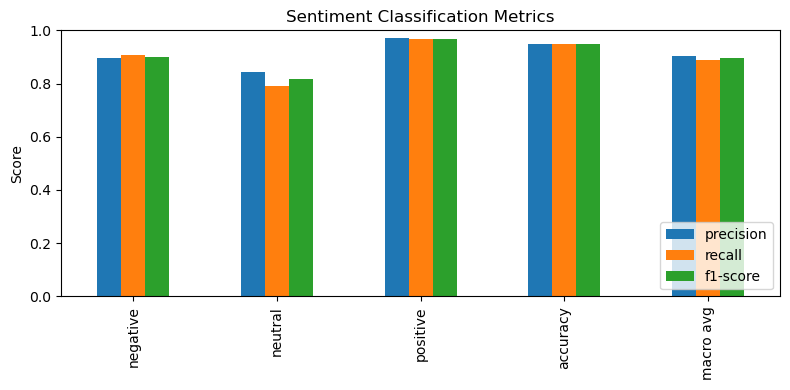

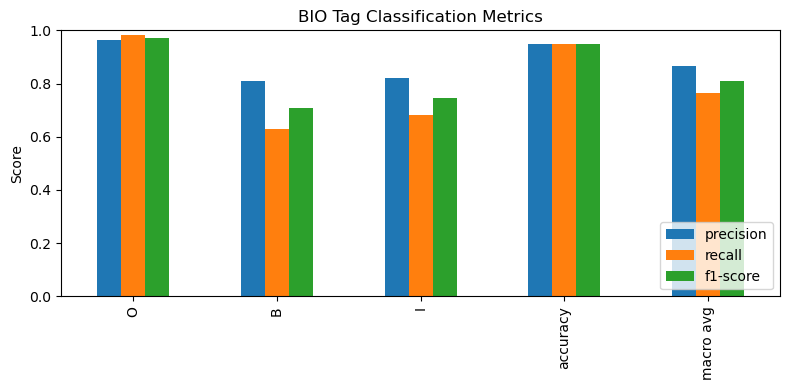

In [16]:
def plot_classification_report(y_true, y_pred, labels, title):
    report = classification_report(
        y_true, y_pred,
        labels=list(range(len(labels))),
        target_names=labels,
        output_dict=True
    )
    df = pd.DataFrame(report).T.iloc[:-1, :3]  # Drop accuracy row
    df.plot(kind='bar', figsize=(8, 4))
    plt.title(title)
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_classification_report(
    true_s_all, pred_s_all,
    labels=label_set,
    title='Sentiment Classification Metrics'
)
plot_classification_report(
    true_b_all, pred_b_all,
    labels=['O', 'B', 'I'],
    title='BIO Tag Classification Metrics'
)


## Training Curves

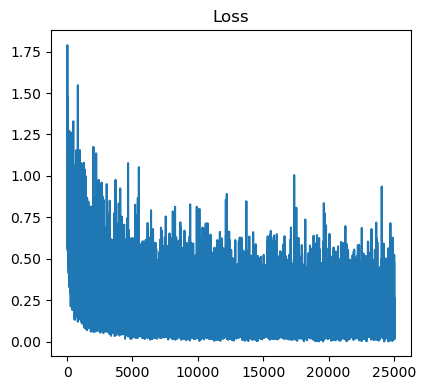

In [21]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.plot(h_losses); plt.title('Loss')
plt.tight_layout()
plt.show()


In [22]:
report = classification_report(true_s_all, pred_s_all, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.8943    0.9066    0.9004     44380
           1     0.8424    0.7916    0.8162      5840
           2     0.9696    0.9680    0.9688    150040

    accuracy                         0.9492    200260
   macro avg     0.9021    0.8887    0.8951    200260
weighted avg     0.9492    0.9492    0.9492    200260



## XAI Visualization Modules

In [18]:
# Try importing LIME for text explanation; if not available, print a warning
try:
    from lime.lime_text import LimeTextExplainer
except ImportError:
    print('LIME not installed; skipping LIME visualization.')

# Define a wrapper model to extract sentiment classification predictions from base + head modules
class WrappedSentModel(nn.Module):
    def __init__(self, base, head):
        super().__init__()
        self.base = base.encoder  # Use only the encoder part of the base model
        self.head = head          # The classification head (contains .sent layer)

    def forward(self, input_ids, attention_mask):
        # Forward pass through base encoder
        enc = self.base(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        # Compute mean-pooled representation (attention-aware)
        pooled = (enc.last_hidden_state * attention_mask.unsqueeze(-1)).sum(1) / \
                 attention_mask.sum(1, keepdim=True)
        # Predict sentiment logits, followed by softmax to get probabilities
        return torch.softmax(self.head.sent(pooled), dim=-1)

# Instantiate the wrapped model and move to correct device
wrapped = WrappedSentModel(base, head).to(DEVICE)


# Saliency Visualization Function
def visualize_saliency(text, cls=0):
    """
    Visualize token-level saliency for a given text and target class.

    Parameters:
        text (str): Input sentence to explain.
        cls (int): Target class index to visualize saliency for.
    """
    # Tokenize the input and move to device
    toked = tok(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)

    # Extract embeddings and enable gradient tracking
    embeds = base.encoder.embed_tokens(toked['input_ids'])
    embeds.requires_grad_()

    # Run forward pass using input embeddings instead of input_ids
    enc = base.encoder(
        inputs_embeds=embeds,
        attention_mask=toked['attention_mask'],
        return_dict=True
    )

    # Mean pooling to get sequence representation
    pooled = (enc.last_hidden_state * toked['attention_mask'].unsqueeze(-1)).sum(1) / \
             toked['attention_mask'].sum(1, keepdim=True)

    # Compute sentiment logits and extract score for the target class
    logits = head.sent(pooled)
    probs = torch.softmax(logits, dim=-1)
    score = probs[0, cls]

    # Clear previous gradients, then perform backward pass
    base.zero_grad()
    head.zero_grad()
    score.backward()

    # Get gradient-based saliency for each token
    grads = embeds.grad[0].abs().sum(dim=-1).cpu().numpy()
    tokens = tok.convert_ids_to_tokens(toked['input_ids'][0])

    # Plot the saliency bar chart
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(tokens)), grads)
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.title(f'Saliency (class={label_set[cls]})')
    plt.tight_layout()
    plt.show()


# Attention Visualization Function
def visualize_attention(text):
    """
    Visualize the self-attention map from the last encoder layer of the base model.

    Parameters:
        text (str): Input sentence to visualize attention.
    """
    # Tokenize input and move to device
    toked = tok(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)

    # Run encoder forward pass with attention output enabled
    out = base.encoder(
        **toked,
        output_attentions=True,
        return_dict=True
    )

    # Extract the attention matrix from the last encoder layer and average across all heads
    matrix = out.attentions[-1][0].mean(0).cpu().numpy()

    # Convert input ids to readable tokens
    tokens = tok.convert_ids_to_tokens(toked['input_ids'][0])

    # Plot the attention heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, interpolation='nearest')
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.title('Encoder Attention')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

## Run XAI Visualizations

[ XAI Sample Analysis ]


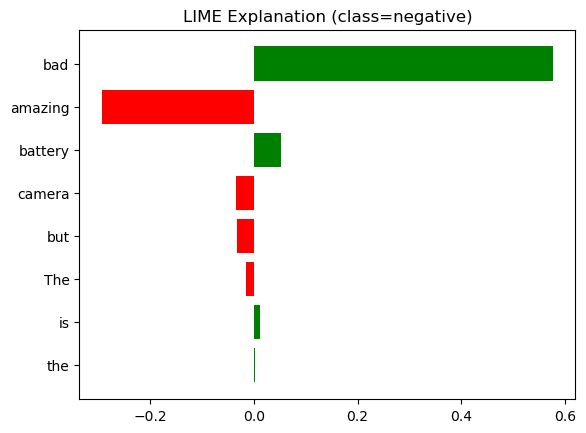

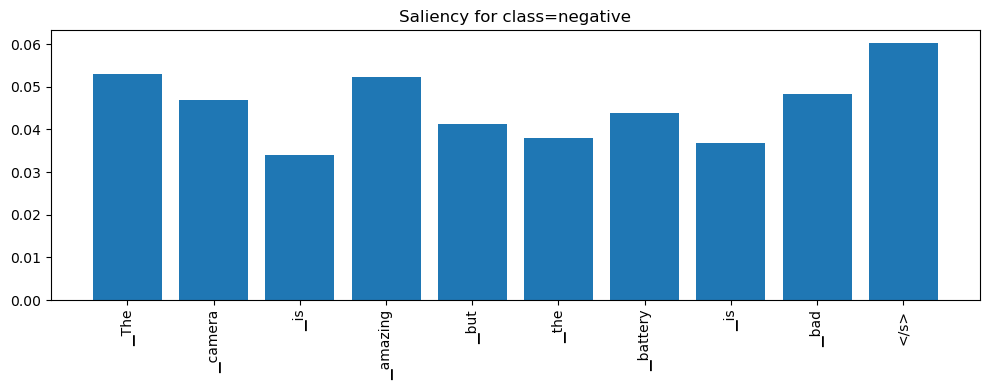

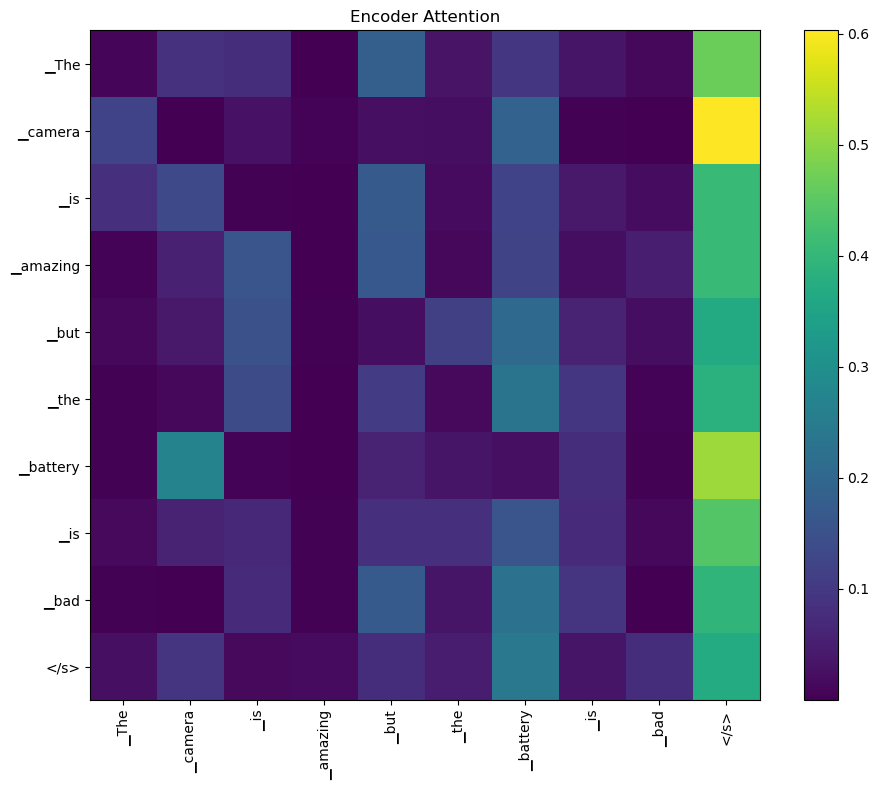

In [20]:
class WrappedSentModel(nn.Module):
    def __init__(self, base, head):
        super().__init__()
        self.base = base.encoder
        self.head = head
    def forward(self, input_ids, attention_mask):
        enc = self.base(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        pooled = (enc.last_hidden_state * attention_mask.unsqueeze(-1)).sum(1) \
                 / attention_mask.sum(1, keepdim=True)
        logits = self.head.sent(pooled)
        return torch.softmax(logits, dim=-1)

wrapped = WrappedSentModel(base, head).to(DEVICE)

def visualize_lime(text, cls=0, num_features=10):
    """
    LIME-based local explanation for a single sentence.
    """
    if LimeTextExplainer is None:
        print("Skipping LIME visualization: lime module not found.")
        return
    explainer = LimeTextExplainer(class_names=label_set)
    def predict_proba(texts):
        toks = tok(
            texts,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=MAX_LEN
        ).to(DEVICE)
        with torch.no_grad():
            out = wrapped(toks['input_ids'], attention_mask=toks['attention_mask'])
        return out.cpu().numpy()

    exp = explainer.explain_instance(
        text,
        predict_proba,
        num_features=num_features,
        labels=[cls]
    )
    fig = exp.as_pyplot_figure(label=cls)
    plt.title(f"LIME Explanation (class={label_set[cls]})")
    plt.show()

def visualize_saliency(text, cls=0):
    """
    Gradient-based saliency visualization.
    """
    toked = tok(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LEN
    ).to(DEVICE)
    input_ids  = toked['input_ids']
    attn_mask  = toked['attention_mask']
    embeds     = base.encoder.embed_tokens(input_ids)
    embeds.requires_grad_()
    enc = base.encoder(
        inputs_embeds=embeds,
        attention_mask=attn_mask,
        return_dict=True
    )
    pooled = (enc.last_hidden_state * attn_mask.unsqueeze(-1)).sum(1) \
             / attn_mask.sum(1, keepdim=True)
    logits = head.sent(pooled)
    probs  = torch.softmax(logits, dim=-1)
    score  = probs[0, cls]
    base.zero_grad(); head.zero_grad()
    score.backward()
    grads  = embeds.grad[0].abs().sum(dim=-1).cpu().numpy()
    tokens = tok.convert_ids_to_tokens(input_ids[0])
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(tokens)), grads)
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.title(f"Saliency for class={label_set[cls]}")
    plt.tight_layout()
    plt.show()

def visualize_attention(text):
    """
    Visualize attention matrix of the last encoder layer.
    """
    toked = tok(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LEN
    ).to(DEVICE)
    with torch.no_grad():
        out = base.encoder(
            **toked,
            output_attentions=True,
            return_dict=True
        )
    attn = out.attentions[-1][0]
    tokens = tok.convert_ids_to_tokens(toked['input_ids'][0])
    matrix = attn.mean(0).cpu().numpy()
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, interpolation='nearest')
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.title("Encoder Attention")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# ---------------- XAI Sample Visualization ----------------
if ENABLE_XAI_VIS:
    print("[ XAI Sample Analysis ]")
    test_sentence = "The camera is amazing but the battery is bad"
    visualize_lime(test_sentence, cls=0)
    visualize_saliency(test_sentence, cls=0)
    visualize_attention(test_sentence)

